In [3]:
#Library Imports

import numpy as np
import pandas as pd

#Visualization libraries
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.offline as pyo
import plotly.graph_objs as go

import json

import warnings
warnings.filterwarnings('ignore')

In [4]:
# Original Data
data= pd.read_csv("india_temp.csv")

In [5]:
data

,States,Period,1901,1902,1903,1904,1905,1906,1907,1908,...,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
0,Andaman and Nicobar,Jan,27.68,26.75,26.70,26.02,26.12,27.62,26.78,26.40,...,26.53,26.78,26.83,25.88,26.29,26.80,26.95,26.79,27.30,27.56
1,Andaman and Nicobar,Feb,28.50,26.67,27.54,26.49,27.29,27.40,26.92,26.29,...,26.87,27.00,27.73,26.46,26.75,26.86,26.83,26.61,27.48,27.14
2,Andaman and Nicobar,Mar,27.03,28.09,27.66,27.55,27.89,26.88,27.04,27.59,...,26.39,27.53,27.84,27.54,27.86,28.29,27.78,27.63,27.88,27.90
3,Andaman and Nicobar,Apr,28.52,29.35,29.53,27.72,28.79,29.62,28.75,29.23,...,27.94,28.48,28.73,28.98,28.39,29.74,28.31,28.18,29.39,28.96
4,Andaman and Nicobar,May,28.28,28.25,29.10,28.02,27.80,29.67,27.42,27.70,...,27.81,27.94,28.40,28.74,28.78,28.60,28.39,27.74,29.06,29.28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
590,West Bengal,Annual,25.35,25.30,25.29,25.08,24.75,25.26,25.13,25.41,...,26.02,25.62,25.47,25.73,25.61,26.07,25.82,25.42,25.73,25.51
591,West Bengal,Winter,18.69,19.72,18.94,19.16,17.93,18.83,19.59,18.87,...,20.01,18.89,19.43,19.80,20.07,19.88,20.36,19.56,19.94,19.03
592,West Bengal,Summer,27.99,28.01,28.17,27.78,26.42,27.81,26.85,28.73,...,28.59,28.48,28.13,28.66,27.89,28.56,27.68,27.62,28.05,27.56
593,West Bengal,Monsoon,28.87,28.63,28.69,28.20,28.68,28.57,28.57,28.70,...,28.88,28.95,28.83,28.78,28.78,29.00,28.89,29.07,29.17,29.02


In [6]:
# Function for zonal-classification of states
def zones(state):
    if state in ['Chandigarh','Delhi','Haryana','Himachal Pradesh','Punjab','Rajasthan']: return 'North'
    elif state in ['Bihar', 'Orissa', 'Jharkhand', 'West Bengal']: return 'East'
    elif state in ['Dadra and Nagar Haveli','Daman and Diu','Goa','Gujarat','Maharashtra']: return 'West'
    elif state in ['Andhra Pradesh','Karnataka','Kerala','Puducherry','Tamil Nadu','Andaman and Nicobar','Lakshadweep']: return 'South'
    elif state in ['Chhattisgarh','Madhya Pradesh','Uttarakhand','Uttar Pradesh']: return 'Central'
    elif state in ['Assam','Sikkim','Nagaland','Meghalaya','Manipur','Mizoram','Tripura','Arunachal Pradesh']: return 'North East'
    else: return None

In [7]:
#creating a copy of data
df=data.copy()

#Calculate basline mean relative to the period 1961-1990
df['Baseline mean']= df.iloc[:,62:92].mean(axis=1).round(2)

#Temp. Change relative to the baseline mean

df= df.melt(id_vars= ['States', 'Period', 'Baseline mean'], var_name= 'Year', value_name= 'temp_change')
df['Year']= df['Year'].astype(int)
df['Zone']= df['States'].apply(zones)
df['temp_change']= df['temp_change']-df['Baseline mean']
df= df[['States', 'Zone', 'Period', 'Year', 'temp_change', 'Baseline mean']]

In [8]:
df

,States,Zone,Period,Year,temp_change,Baseline mean
0,Andaman and Nicobar,South,Jan,1901,1.87,25.81
1,Andaman and Nicobar,South,Feb,1901,2.44,26.06
2,Andaman and Nicobar,South,Mar,1901,0.12,26.91
3,Andaman and Nicobar,South,Apr,1901,0.42,28.10
4,Andaman and Nicobar,South,May,1901,0.59,27.69
...,...,...,...,...,...,...
71395,West Bengal,East,Annual,2020,-0.05,25.56
71396,West Bengal,East,Winter,2020,-0.64,19.67
71397,West Bengal,East,Summer,2020,-0.60,28.16
71398,West Bengal,East,Monsoon,2020,0.46,28.56


In [ ]:
df.describe()['temp_change']

,temp_change
count,71400.000000
mean,0.068737
std,0.712529
min,-4.240000
25%,-0.360000
50%,0.040000
75%,0.490000
max,4.330000


In [ ]:
import pandas as pd

# Assuming df is your original DataFrame
# Filter for 'Annual' period onl

# Find the mean temperature change for the year 2016
mean_2016 = df['temp_change'].mean()

# Find the maximum temperature change overall
max_change = df['temp_change'].max()

# Find the minimum temperature change overall
min_change = df['temp_change'].min()

# Print the results
print(f'Mean temperature change : {mean_2016:.2f} °C')
print(f'Maximum temperature change overall: {max_change:.2f} °C')
print(f'Minimum temperature change overall: {min_change:.2f} °C')


Mean temperature change : 0.07 °C
Maximum temperature change overall: 4.33 °C
Minimum temperature change overall: -4.24 °C


In [ ]:
# Filter for 'Annual' period only
df_annual = df[df['Period'] == 'Annual']

# Calculate descriptive statistics
mean_temp_change = df_annual['temp_change'].mean()
median_temp_change = df_annual['temp_change'].median()
std_dev_temp_change = df_annual['temp_change'].std()
variance_temp_change = df_annual['temp_change'].var()
min_temp_change = df_annual['temp_change'].min()
max_temp_change = df_annual['temp_change'].max()
quartiles = df_annual['temp_change'].quantile([0.25, 0.5, 0.75])
skewness = df_annual['temp_change'].skew()
kurtosis = df_annual['temp_change'].kurt()

# Count of observations
count_obs = df_annual['temp_change'].count()

# Print the results
print(f"Mean Temperature Change: {mean_temp_change:.4f}")
print(f"Median Temperature Change: {median_temp_change:.4f}")
print(f"Standard Deviation: {std_dev_temp_change:.4f}")
print(f"Variance: {variance_temp_change:.4f}")
print(f"Minimum Temperature Change: {min_temp_change:.4f}")
print(f"Maximum Temperature Change: {max_temp_change:.4f}")
print(f"Quartiles:\n{quartiles}")
print(f"Skewness: {skewness:.4f}")
print(f"Kurtosis: {kurtosis:.4f}")
print(f"Count of Observations: {count_obs}")

Mean Temperature Change: 0.0689
Median Temperature Change: 0.0300
Standard Deviation: 0.4161
Variance: 0.1732
Minimum Temperature Change: -1.0500
Maximum Temperature Change: 1.6500
Quartiles:
0.25   -0.24
0.50    0.03
0.75    0.33
Name: temp_change, dtype: float64
Skewness: 0.4279
Kurtosis: 0.0667
Count of Observations: 4200


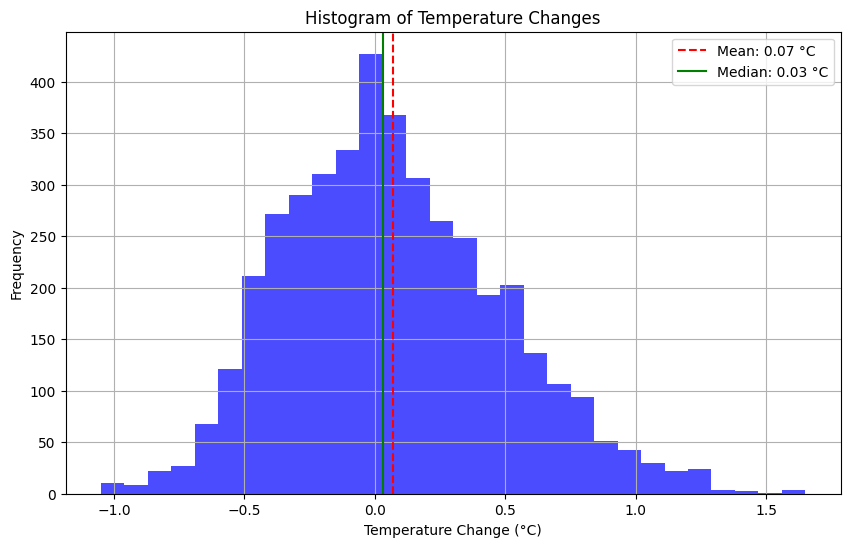

In [ ]:
# Histogram of temperature changes

mean_temp_change = np.mean(df_annual['temp_change'])
median_temp_change = np.median(df_annual['temp_change'])
plt.figure(figsize=(10, 6))
plt.hist(df_annual['temp_change'], bins=30, alpha=0.7, color='blue')
plt.title('Histogram of Temperature Changes')
plt.xlabel('Temperature Change (°C)')
plt.ylabel('Frequency')
plt.legend()
# Add vertical lines for mean and median
plt.axvline(mean_temp_change, color='red', linestyle='--', label=f'Mean: {mean_temp_change:.2f} °C')
plt.axvline(median_temp_change, color='green', linestyle='-', label=f'Median: {median_temp_change:.2f} °C')
plt.grid()
plt.legend()
plt.xlim()
plt.show()

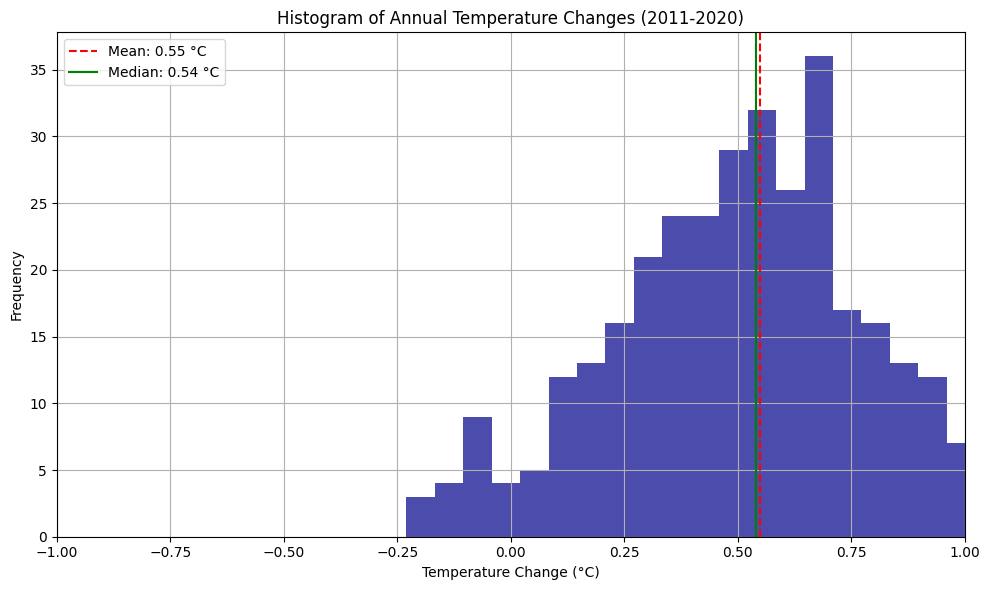

In [ ]:
import numpy as np

# Filter data for 'Annual' period and years 2011 to 2020
df_filtered_annual_2011_2020 = df_annual[(df_annual['Period'] == 'Annual') &
                                         (df_annual['Year'] >= 2011) &
                                         (df_annual['Year'] <= 2020)]

# Calculate mean and median
mean_temp_change = np.mean(df_filtered_annual_2011_2020['temp_change'])
median_temp_change = np.median(df_filtered_annual_2011_2020['temp_change'])

# Plot the histogram for temperature changes from 2011 to 2020 for Annual data
plt.figure(figsize=(10, 6))
plt.hist(df_filtered_annual_2011_2020['temp_change'], bins=30, alpha=0.7, color='darkblue')

# Set the x-axis limits from -1 to 1
plt.xlim(-1, 1)

# Add vertical lines for mean and median
plt.axvline(mean_temp_change, color='red', linestyle='--', label=f'Mean: {mean_temp_change:.2f} °C')
plt.axvline(median_temp_change, color='green', linestyle='-', label=f'Median: {median_temp_change:.2f} °C')

# Adding labels and title
plt.title('Histogram of Annual Temperature Changes (2011-2020)')
plt.xlabel('Temperature Change (°C)')
plt.ylabel('Frequency')

# Adding grid and legend
plt.grid()
plt.legend()

# Show plot
plt.tight_layout()
plt.show()


In [ ]:
# Which ten states/UTs suffered the most from temperature change in the last ten years?

df_c= df[ (df.Period=='Annual') & (df.Year.between(2011,2020)) ][['States', 'temp_change']]
df_c= df_c.groupby('States').mean().round(2).nlargest(10, 'temp_change')
df_c.reset_index(inplace=True)

fig= px.bar(df_c, x='States', y='temp_change', text_auto='.2f',
            title= 'Ten States/UTs which suffered the most from temperature change in the last ten years (2011-2020)',
            color='temp_change',
            color_continuous_scale= 'teal'
           )

fig.update_layout(
    width=1000,
    height=600,
    template='plotly_dark',
    coloraxis_showscale=False,
    title_x= 0.5

)
fig.update_traces(textposition='outside')
fig.update_xaxes( title='States/UTs')
fig.update_yaxes( title='Temperature Change (°C)')

fig

In [ ]:
# Which ten states/UTs suffered the least from temperature change in the last ten years?

df_c= df[ (df.Period=='Annual') & (df.Year.between(2011,2020)) ][['States', 'temp_change']]
df_c= df_c.groupby('States').mean().round(2).nsmallest(10, 'temp_change')
df_c.reset_index(inplace=True)

fig= px.bar(df_c, x='States', y='temp_change', text_auto='.2f',
            title= 'Ten States/UTs which suffered the least from temperature change in the last ten years (2011-2020)',
            color='temp_change',
            color_continuous_scale= 'teal'
           )

fig.update_layout(
    width=1000,
    height= 600,
    template='plotly_dark',
    coloraxis_showscale=False,
    title_x= 0.5

)
fig.update_traces(textposition='outside')
fig.update_yaxes( title='Temperature Change (°C)')

fig

In [ ]:
# Filter data for the annual period and between 2011 and 2020
df_zone = df[(df.Period == 'Annual') & (df.Year.between(2011, 2020))]

# Group by Zone and calculate mean temperature change
df_zone_avg = df_zone.groupby(['Zone'])['temp_change'].mean().reset_index()

# Create a bar plot using Plotly
fig = px.bar(
    df_zone_avg,
    x='Zone',
    y='temp_change',
    text_auto='.2f',
    title='Average Temperature Change by Zone (2011-2020)',
    color='temp_change',
    color_continuous_scale='teal'
)

# Update layout
fig.update_layout(
    width=1000,
    height=600,
    template='plotly_dark',
    coloraxis_showscale=True,
    title_x=0.5
)
fig.update_traces(textposition='outside')
fig.update_yaxes(title='Average Temperature Change (°C)')

# Show the figure
fig.show()


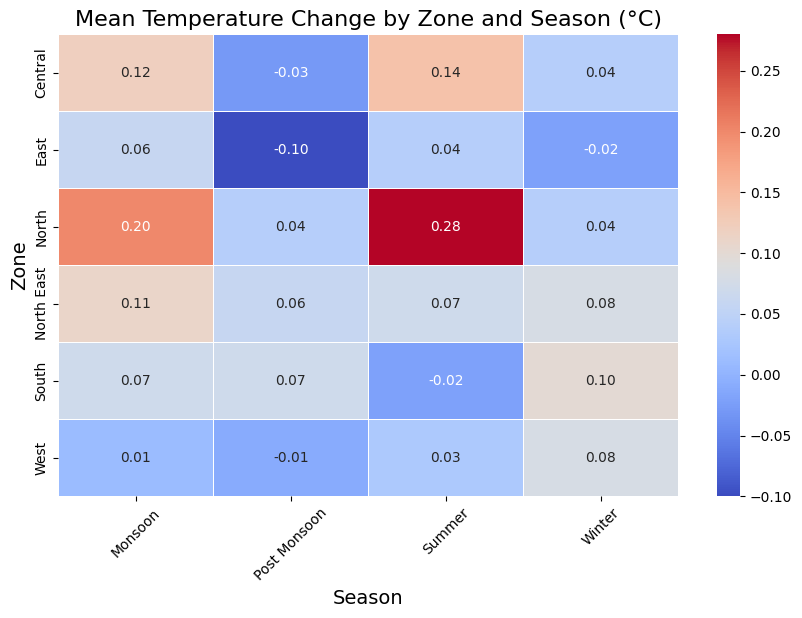

In [ ]:

# Filter data for the relevant periods
df_filtered = df[df['Period'].isin(['Summer', 'Monsoon', 'Winter', 'Post Monsoon'])]

# Group by Zone and Period to calculate mean temperature change
mean_temp_change_by_zone_season = df_filtered.groupby(['Zone', 'Period'])['temp_change'].mean().reset_index()

# Round the results for better readability
mean_temp_change_by_zone_season['temp_change'] = mean_temp_change_by_zone_season['temp_change'].round(2)

# Create a pivot table for better visualization
pivot_table = mean_temp_change_by_zone_season.pivot(index='Zone', columns='Period', values='temp_change')



plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Mean Temperature Change by Zone and Season (°C)', fontsize=16)
plt.xlabel('Season', fontsize=14)
plt.ylabel('Zone', fontsize=14)
plt.xticks(rotation=45)
plt.show()



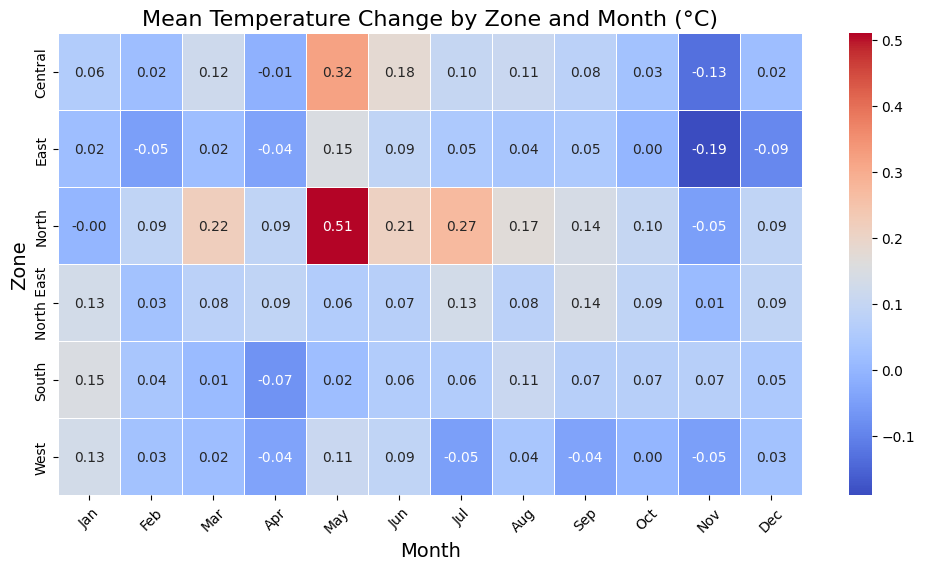

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Sample DataFrame structure (replace this with your actual DataFrame)
# df = pd.read_csv('your_data.csv')

# Define the months as they appear in your 'Period' column
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Filter data for the relevant months
df_filtered = df[df['Period'].isin(months)]

# Group by Zone and Month to calculate mean temperature change
mean_temp_change_by_zone_month = df_filtered.groupby(['Zone', 'Period'])['temp_change'].mean().reset_index()

# Round the results for better readability
mean_temp_change_by_zone_month['temp_change'] = mean_temp_change_by_zone_month['temp_change'].round(2)

# Create a pivot table for better visualization
pivot_table = mean_temp_change_by_zone_month.pivot(index='Zone', columns='Period', values='temp_change')

# Set the order of columns to match the month sequence
pivot_table = pivot_table.reindex(columns=months)

# Create the heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(pivot_table, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Mean Temperature Change by Zone and Month (°C)', fontsize=16)
plt.xlabel('Month', fontsize=14)
plt.ylabel('Zone', fontsize=14)
plt.xticks(rotation=45)
plt.show()


In [ ]:
=import plotly.express as px
import pandas as pd

# Filter data for the annual period
df_year_zone = df[df['Period'] == 'Annual']

# Group by Year to calculate mean temperature change
df_year_zone_avg = df_year_zone.groupby(['Year'])['temp_change'].mean().reset_index()

# Find highest change in 2009 and lowest in 1917
highest_change_year = df_year_zone_avg.loc[df_year_zone_avg['Year'] == 2009, 'temp_change'].values[0]
lowest_change_year = df_year_zone_avg.loc[df_year_zone_avg['Year'] == 1917, 'temp_change'].values[0]

# Create a bar plot using Plotly
fig = px.bar(
    df_year_zone_avg,
    x='Year',
    y='temp_change',
    text_auto='.2f',
    title='Average Temperature Change by Zone (1900-2020)',
    barmode='group'
)

# Update layout
fig.update_layout(
    width=1000,
    height=600,
    template='plotly_dark',
    title_x=0.5
)

# Add annotations for the highest and lowest changes
fig.add_annotation(
    x=2009,
    y=highest_change_year,
    text=f'Highest Change: {highest_change_year:.2f} °C',
    showarrow=True,
    arrowhead=2,
    ax=-20,
    ay=-30
)

fig.add_annotation(
    x=1917,
    y=lowest_change_year,
    text=f'Lowest Change: {lowest_change_year:.2f} °C',
    showarrow=True,
    arrowhead=2,
    ax=-20,
    ay=30
)

# Update traces
fig.update_traces(textposition='outside')
fig.update_yaxes(title='Average Temperature Change (°C)')

# Show the figure
fig.show()


In [ ]:
import pandas as pd
import plotly.express as px

# Assuming df is your original DataFrame

# Filter data for the annual period and years 2011 to 2020
df_filtered = df[(df['Period'] == 'Annual') & (df['Year'].between(2011, 2020))]

# Group by States and Zone to calculate mean temperature change
df_state_zone_avg = df_filtered.groupby(['States', 'Zone'])['temp_change'].mean().reset_index()

# Create a bar plot using Plotly
figsize( )
fig = px.bar(
    df_state_zone_avg,
    x='States',
    y='temp_change',
    color='Zone',
    title='Average Temperature Change by State and Zone (2011-2020)',
    barmode='group'
)

# Update layout
fig.update_layout(template='plotly_dark', xaxis_title='States', yaxis_title='Average Temperature Change (°C)')

# Find the highest and lowest temperature change
highest_change = df_state_zone_avg['temp_change'].max()
lowest_change = df_state_zone_avg['temp_change'].min()

# Get the corresponding states for highest and lowest changes
highest_state = df_state_zone_avg.loc[df_state_zone_avg['temp_change'] == highest_change, 'States'].values[0]
lowest_state = df_state_zone_avg.loc[df_state_zone_avg['temp_change'] == lowest_change, 'States'].values[0]

# Add annotations for the highest and lowest changes
fig.add_annotation(
    x=highest_state,
    y=highest_change,
    text=f'Highest Change: {highest_change:.2f} °C',
    showarrow=True,
    arrowhead=2,
    ax=20,  # Adjust horizontal position
    ay=-50  # Adjust vertical position
)

fig.add_annotation(
    x=lowest_state,
    y=lowest_change,
    text=f'Lowest Change: {lowest_change:.2f} °C',
    showarrow=True,
    arrowhead=5,
    ax=20,  # Adjust horizontal position
    ay=-50  # Adjust vertical position
)

# Show the figure
fig.show()


In [ ]:
import folium
import json
import pandas as pd

# Load GeoJSON data for Indian states
indian_states = json.load(open('in.json', 'r'))

# Assuming df is your DataFrame that contains the temperature data
# Filter the DataFrame for annual data between 2011 and 2020
x = df[(df.Period == 'Annual') & (df.Year.between(2011, 2020))]

# Group by States and calculate the mean temperature change
x = x.groupby('States')['temp_change'].mean().reset_index()
x['temp_change'] = x['temp_change'].round(2)

# Create a Folium map
fig = folium.Map(location=[21.9149, 78.0281], zoom_start=4 , tiles='CartoDB positron')

# Add Choropleth layer
folium.Choropleth(
    geo_data=indian_states,
    data=x,
    columns=['States', 'temp_change'],
    key_on='feature.properties.name',  # Ensure this matches the GeoJSON property
    fill_color='YlOrRd',  # Changed color for better visibility
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name='Average Temperature Change (°C)',
    bins=9,
    nan_fill_color='grey',
).add_to(fig)

# Display the map
fig


In [ ]:
df0= df[ (df.States=='India') & (df.Year>1960)]
df1= df0[df0.Period=='Winter']
df2= df0[df0.Period=='Summer']
df3= df0[df0.Period=='Monsoon']
df4= df0[df0.Period=='Post Monsoon']

fig = go.Figure()
fig.add_trace(go.Scatter(x=df1.Year, y=df1.temp_change,
                    mode='markers',
                    name='Winter'))
fig.add_trace(go.Scatter(x=df2.Year, y=df2.temp_change,
                    mode='markers',
                    name='Summer'))
fig.add_trace(go.Scatter(x=df3.Year, y=df3.temp_change,
                    mode='markers',
                    name='Monsoon'))
fig.add_trace(go.Scatter(x=df4.Year, y=df4.temp_change,
                    mode='markers',
                    name='Post Monsoon'))

fig.add_annotation(
    x=48,
    y=1.97,
    xref="x",
    yref="y",
    text="Hottest Winter (2009, 1.97)",
    xanchor= 'right',
    showarrow=True,
    font=dict(
            family="Courier New, monospace",
            size=16,
            color="#ffffff"
            ),
    align="center",
    arrowhead=2,
    arrowsize=1,
    arrowwidth=2,
    arrowcolor="#636363",
    ax=-20,
    ay=10,
    bordercolor="#c7c7c7",
    borderwidth=2,
    borderpad=4,
    bgcolor="#ff7f0e",
    opacity=1
)

fig.add_annotation(
    x=49,
    y=1.96,
    xref="x",
    yref="y",
    text="Hottest Summer (2010, 1.96)",
    xanchor= 'center',
    showarrow=True,
    font=dict(
            family="Courier New, monospace",
            size=16,
            color="#ffffff"
            ),
    align="center",
    arrowhead=2,
    arrowsize=1,
    arrowwidth=2,
    arrowcolor="#636363",
    ax=-15,
    ay=-30,
    bordercolor="#c7c7c7",
    borderwidth=2,
    borderpad=4,
    bgcolor="#ff7f0e",
    opacity=1
)


fig.update_layout(
    width=1000,
    height= 600,
    template='seaborn',
    paper_bgcolor="rgb(234, 234, 242)",
    title='Season-wise temperature change in India (1961-2020)',
    title_x=0.5,
    title_y=0.95,

    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="right",
        x=1
    )
)

fig.update_xaxes(type='category',title='Years')
fig.update_yaxes(title='Temperature Change (°C)')

fig.show()

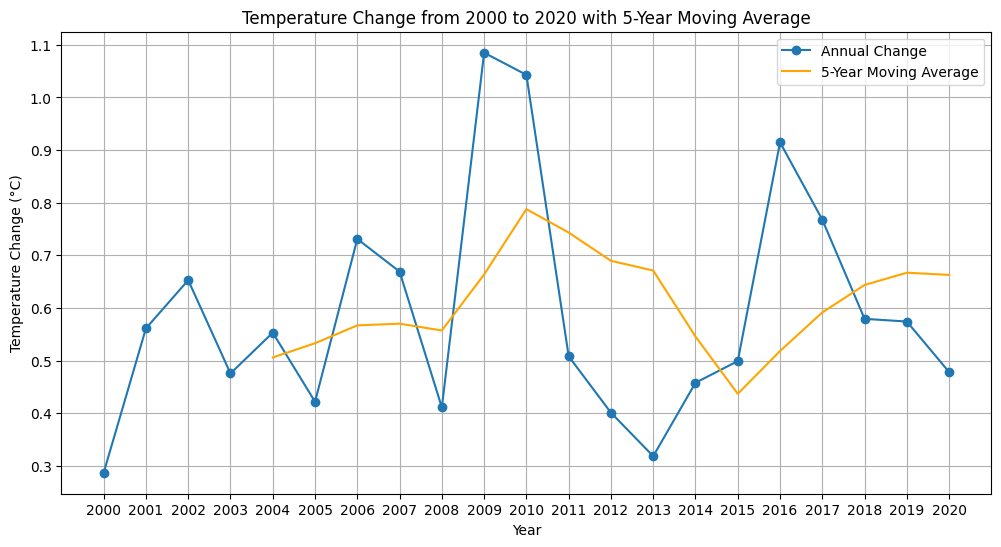

In [ ]:
df_annual = df[df['Period'] == 'Annual']

# Filter for the years 2000 to 2020
df_filtered = df_annual[(df_annual['Year'] >= 2000) & (df_annual['Year'] <= 2020)]

# Group by Year and calculate the average temperature change
df_yearly_avg = df_filtered.groupby('Year')['temp_change'].mean().reset_index()

# Set the 'Year' as the index
df_yearly_avg.set_index('Year', inplace=True)

# Calculate the 5-year moving average
df_yearly_avg['Moving Average'] = df_yearly_avg['temp_change'].rolling(window=5).mean()

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(df_yearly_avg.index, df_yearly_avg['temp_change'], label='Annual Change', marker='o')
plt.plot(df_yearly_avg.index, df_yearly_avg['Moving Average'], label='5-Year Moving Average', color='orange')
plt.title('Temperature Change from 2000 to 2020 with 5-Year Moving Average')
plt.xlabel('Year')
plt.ylabel('Temperature Change (°C)')
plt.xticks(df_yearly_avg.index)  # Set x-ticks to show all years in the range
plt.legend()
plt.grid()
plt.show()


Mean Absolute Error: 0.2265
Mean Squared Error: 0.0819
Root Mean Squared Error: 0.2862
   Year  Forecasted Temperature Change (°C)
0  2021                            0.507015
1  2022                            0.514155
2  2023                            0.521295
3  2024                            0.528435


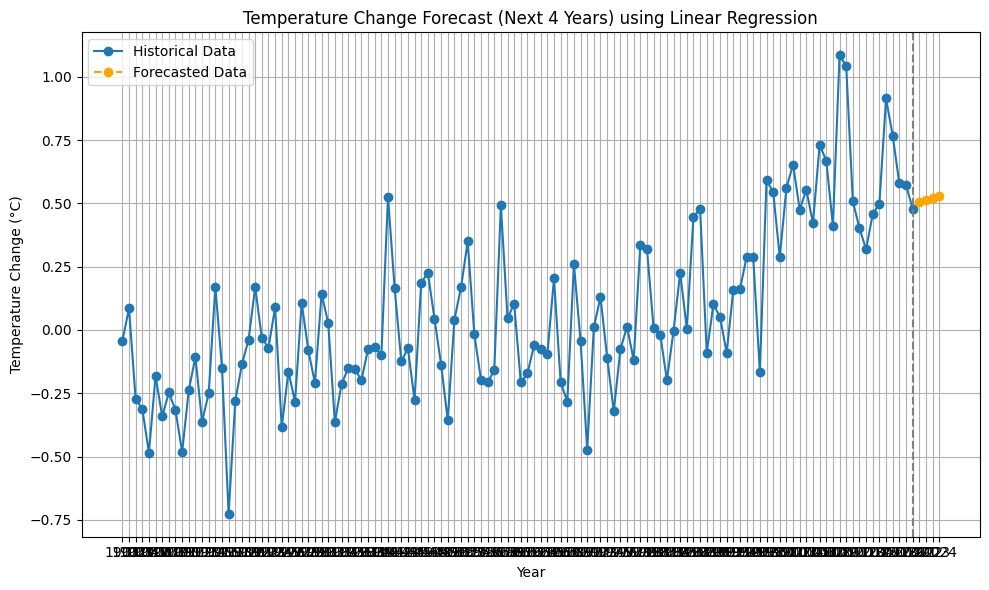

In [ ]:
te

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning:

No supported index is available. Prediction results will be given with an integer index beginning at `start`.

/usr/local/lib/python3.10/dist-packages/st

     Year  Forecasted Temperature Change (°C)
120  2021                            0.560578
121  2022                            0.576405
122  2023                            0.579448
123  2024                            0.580034
Mean Absolute Error: 0.0793
Mean Squared Error: 0.0133 
Root Mean Squared Error: 0.1154


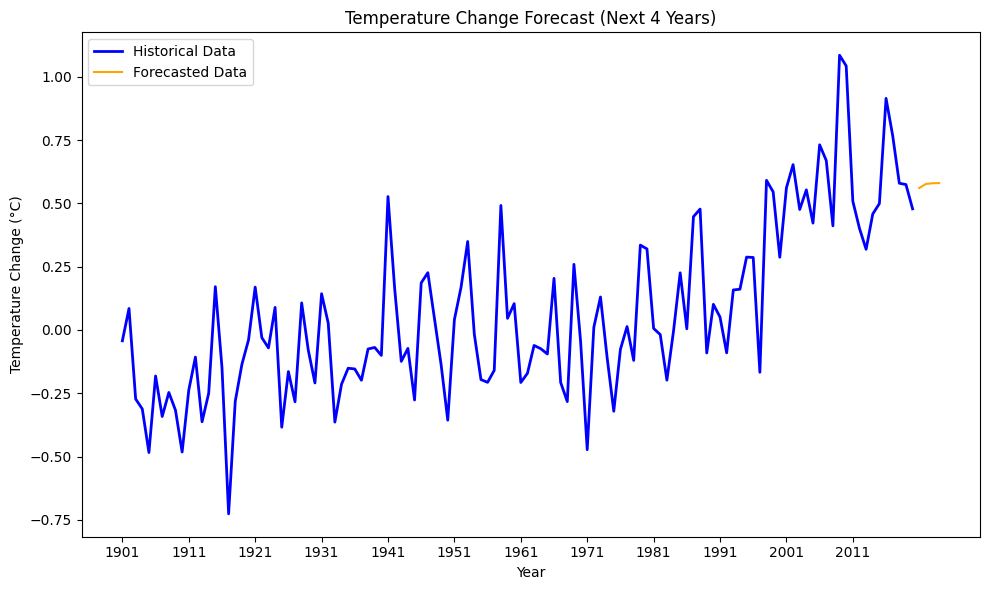

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Assuming df is your original DataFrame
# Filter for 'Annual' period only
df_annual = df[df['Period'] == 'Annual']

# Filter for years from 2000 to 2020
df_filtered = df_annual[(df_annual['Year'] >= 1901) & (df_annual['Year'] <= 2020)]

# Group by Year and calculate the average temperature change
df_yearly_avg = df_filtered.groupby('Year')['temp_change'].mean().reset_index()

# Set the 'Year' as the index
df_yearly_avg.set_index('Year', inplace=True)

# Fit the ARIMA model
model = ARIMA(df_yearly_avg['temp_change'], order=(1, 1, 1))
model_fit = model.fit()

# Forecast the next four years
forecast = model_fit.forecast(steps=4)

# Create a DataFrame for the forecast
forecast_years = [df_yearly_avg.index[-1] + i for i in range(1, 5)]  # Next four years
forecast_df = pd.DataFrame({
    'Year': forecast_years,
    'Forecasted Temperature Change (°C)': forecast
})

# Display the forecast DataFrame
print(forecast_df)

# Evaluate model performance on the historical data
# We need to forecast the same years we have historical data for
# For evaluation, let's take the last 4 years of historical data for comparison
historical_forecast = model_fit.get_forecast(steps=4)
predicted = historical_forecast.predicted_mean
actual = df_yearly_avg['temp_change'][-4:].values  # Last 4 actual values

# Calculate evaluation metrics
mae = mean_absolute_error(actual, predicted)
mse = mean_squared_error(actual, predicted)
rmse = np.sqrt(mse)

print(f"Mean Absolute Error: {mae:.4f}" )
print(f"Mean Squared Error: {mse:.4f} ")
print(f"Root Mean Squared Error: {rmse:.4f}")


# Plot the historical and forecasted data
plt.figure(figsize=(10, 6))
plt.plot(df_yearly_avg.index, df_yearly_avg['temp_change'], label='Historical Data', color='blue', linewidth=2)
plt.plot(forecast_df['Year'], forecast_df['Forecasted Temperature Change (°C)'], label='Forecasted Data', color='orange')
plt.title('Temperature Change Forecast (Next 4 Years)')
plt.xlabel('Year')
plt.ylabel('Temperature Change (°C)')

# Set x-ticks to show every 10 years for clarity
plt.xticks(ticks=np.arange(df_yearly_avg.index.min(), df_yearly_avg.index.max() + 1, 10))

plt.legend()
plt.tight_layout()

# Remove grid
plt.grid(False)

plt.show()




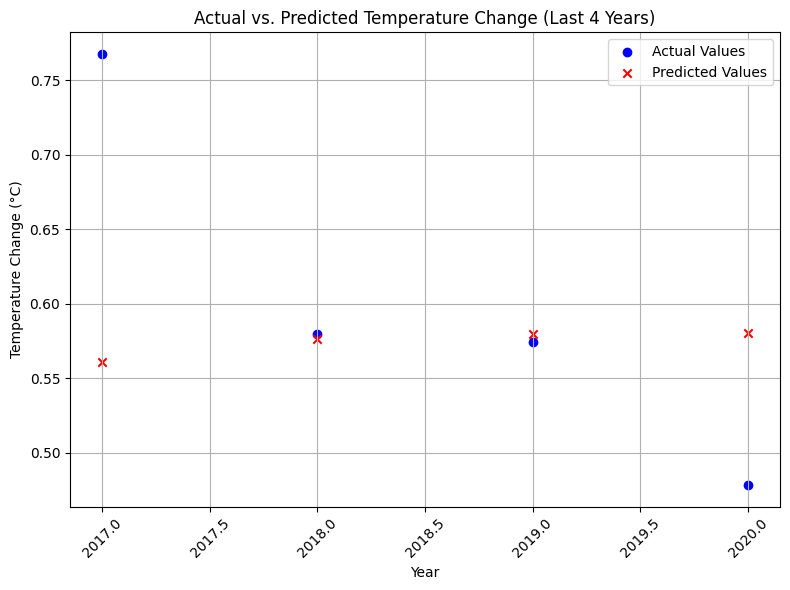

In [ ]:
import matplotlib.pyplot as plt

# Scatter plot for model accuracy (Actual vs. Predicted)
plt.figure(figsize=(8, 6))

# Plotting actual values (blue 'o' markers)
plt.scatter(df_yearly_avg.index[-4:], actual, color='blue', label='Actual Values', marker='o')

# Plotting predicted values (red 'x' markers)
plt.scatter(df_yearly_avg.index[-4:], predicted, color='red', label='Predicted Values', marker='x')

# Adding labels and title
plt.title('Actual vs. Predicted Temperature Change (Last 4 Years)')
plt.xlabel('Year')
plt.ylabel('Temperature Change (°C)')
plt.xticks(rotation=45)  # Rotate year labels for better readability

# Adding grid and legend
plt.grid(True)
plt.legend()

# Show plot
plt.tight_layout()
plt.show()


In [ ]:
# Null = The mean temperature change for the last 20 years is equal to the overall historical mean temperature change.

# Alternative = The mean temperature change for the last 20 years is not equal to the overall historical mean temperature change.



last_20_years = df[(df['Year'] >= 2001) & (df['Year'] <= 2020)]

# Calculate mean for the last 20 years
mean_last_20 = last_20_years['temp_change'].mean()

# Calculate overall historical mean
overall_mean = df['temp_change'].mean()

# Z-test calculation
std_dev = df['temp_change'].std(ddof=1)  # Sample standard deviation
n_last_20 = len(last_20_years)  # Sample size for the last 20 years

# Z-test statistic
z_stat = (mean_last_20 - overall_mean) / (std_dev / (n_last_20 ** 0.5))
p_value = stats.norm.sf(abs(z_stat)) * 2  # Two-tailed p-value

# Display results
print(f'Historical Average: {overall_mean:.4f}')
print(f'Last 20 Years Average: {mean_last_20:.4f}')
print(f'Z-test statistic for last 20 years: {z_stat:.4f}')
print(f'P-value: {p_value:.4f}')

Historical Average: 0.0687
Last 20 Years Average: 0.6104
Z-test statistic for last 20 years: 82.9255
P-value: 0.0000


In [ ]:
last_20_years = df[(df['Year'] >= 2001) & (df['Year'] <= 2020)]

# Extract temperature changes for West and East zones
west_data = last_20_years[last_20_years['Zone'] == 'West']['temp_change']
east_data = last_20_years[last_20_years['Zone'] == 'East']['temp_change']

# Perform two-sample t-test
t_stat, p_value = stats.ttest_ind(west_data, east_data)

# Display results
print(f'T-test statistic (West vs. East): {t_stat:.4f}')
print(f'P-value: {p_value:.4f}')

if p_value < 0.05:
    print("Reject the null hypothesis: There is a significant difference in mean temperature changes between the West and East zones.")
    if t_stat > 0:
        print("The West zone has a higher mean temperature change than the East zone.")
else:
    print("Fail to reject the null hypothesis: There is no significant difference in mean temperature changes between the West and East zones.")

T-test statistic (West vs. East): 5.1265
P-value: 0.0000
Reject the null hypothesis: There is a significant difference in mean temperature changes between the West and East zones.
The West zone has a higher mean temperature change than the East zone.


In [ ]:
last_20_years = df[(df['Year'] >= 2001) & (df['Year'] <= 2020)]

# Extract temperature changes for North and Northeast zones
north_data = last_20_years[last_20_years['Zone'] == 'North']['temp_change']
northeast_data = last_20_years[last_20_years['Zone'] == 'North East']['temp_change']

# Perform two-sample t-test
t_stat, p_value = stats.ttest_ind(north_data, northeast_data)

# Display results
print(f'T-test statistic (North vs. Northeast): {t_stat:.4f}')
print(f'P-value: {p_value:.4f}')

# Interpretation and Conclusion
if p_value < 0.05:
    print("Reject the null hypothesis: There is a significant difference in mean temperature changes between the North and Northeast zones.")
    if t_stat > 0:
        print("The North zone has a higher mean temperature change than the Northeast zone.")
    else:
        print("The Northeast zone has a higher mean temperature change than the North zone.")
else:
    print("Fail to reject the null hypothesis: There is no significant difference in mean temperature changes between the North and Northeast zones.")

T-test statistic (North vs. Northeast): 9.5759
P-value: 0.0000
Reject the null hypothesis: There is a significant difference in mean temperature changes between the North and Northeast zones.
The North zone has a higher mean temperature change than the Northeast zone.


In [ ]:
seasons = ['Summer', 'Monsoon', 'Post Monsoon', 'Winter']
df_seasons = df[df['Period'].isin(seasons)]

# Perform ANOVA
model = ols('temp_change ~ Period', data=df_seasons).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

# Display results
print(anova_table)

# Print Null and Alternative Hypotheses
print("\nNull Hypothesis (H0): There is no significant difference in mean temperature changes among the seasons.")
print("Alternative Hypothesis (H1): There is a significant difference in mean temperature changes among the seasons.")

# Conclusions based on ANOVA results
sum_sq = anova_table['sum_sq']['Period']
df_period = anova_table['df']['Period']
f_statistic = anova_table['F']['Period']
p_value = anova_table['PR(>F)']['Period']

print("\nConclusions:")
print(f"Sum of Squares (Period): {sum_sq:.2f}")
print("This indicates the variability in temperature changes explained by the different periods (seasons).")
print(f"Degrees of Freedom (df): {df_period:.1f}")
print("This represents the number of groups minus one (number of seasons - 1).")
print(f"F-statistic: {f_statistic:.2f}")
print("A higher F-statistic indicates a significant difference between the means of the groups.")
print(f"P-value (PR(>F)): {p_value:.2e}")
print("This p-value is extremely low, suggesting strong evidence against the null hypothesis.")

               sum_sq       df          F        PR(>F)
Period      15.342063      3.0  13.639273  6.970269e-09
Residual  6297.629919  16796.0        NaN           NaN

Null Hypothesis (H0): There is no significant difference in mean temperature changes among the seasons.
Alternative Hypothesis (H1): There is a significant difference in mean temperature changes among the seasons.

Conclusions:
Sum of Squares (Period): 15.34
This indicates the variability in temperature changes explained by the different periods (seasons).
Degrees of Freedom (df): 3.0
This represents the number of groups minus one (number of seasons - 1).
F-statistic: 13.64
A higher F-statistic indicates a significant difference between the means of the groups.
P-value (PR(>F)): 6.97e-09
This p-value is extremely low, suggesting strong evidence against the null hypothesis.
